In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [5]:
df = pd.read_csv('ai_student_impact_dataset (1).csv')

In [6]:
df.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


In [7]:
df.isnull().sum()

,0
Student_ID,0
Major_Category,0
Year_of_Study,0
Pre_Semester_GPA,0
Weekly_GenAI_Hours,0
Primary_Use_Case,0
Prompt_Engineering_Skill,0
Tool_Diversity,0
Paid_Subscription,0
Traditional_Study_Hours,0


In [8]:
df.shape

(50000, 16)

In [9]:
df.describe()

,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
count,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,125000.500000,3.146102,8.427752,2.80026,11.209271,3.505360,4.270760,3.349299,75.798125
std,14433.901067,0.478854,8.269490,1.18802,5.156426,1.820812,2.144066,0.495673,13.281626
min,100001.000000,1.183000,0.000000,1.00000,1.000000,1.000000,1.000000,1.000000,10.780000
25%,112500.750000,2.834000,2.390000,2.00000,7.560000,2.000000,3.000000,3.023750,66.820000
50%,125000.500000,3.210000,5.800000,3.00000,11.180000,3.000000,4.000000,3.421000,76.000000
75%,137500.250000,3.521000,11.720000,4.00000,14.710000,5.000000,6.000000,3.749000,85.190000
max,150000.000000,3.998000,40.000000,5.00000,35.860000,10.000000,10.000000,4.000000,100.000000


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  object 
 2   Year_of_Study               50000 non-null  object 
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  object 
 6   Prompt_Engineering_Skill    50000 non-null  object 
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  object 
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           500

In [11]:
df.corr(numeric_only=True)

,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
Student_ID,1.000000,0.002275,0.001577,-0.001187,-0.000319,0.000648,0.002768,0.009670,-0.000602,-0.001737
Pre_Semester_GPA,0.002275,1.000000,-0.001084,-0.005671,-0.001027,-0.004620,0.000701,-0.000667,0.926781,0.099019
Weekly_GenAI_Hours,0.001577,-0.001084,1.000000,0.008411,0.196943,-0.157368,0.665479,0.269080,-0.018600,-0.118099
Tool_Diversity,-0.001187,-0.005671,0.008411,1.000000,0.005803,0.003565,0.006019,0.003189,0.025265,0.196952
Paid_Subscription,-0.000319,-0.001027,0.196943,0.005803,1.000000,-0.035329,0.131033,0.065845,0.005528,-0.024083
Traditional_Study_Hours,0.000648,-0.004620,-0.157368,0.003565,-0.035329,1.000000,-0.102625,-0.040935,0.137653,0.147565
Perceived_AI_Dependency,0.002768,0.000701,0.665479,0.006019,0.131033,-0.102625,1.000000,0.307620,-0.014180,-0.084324
Anxiety_Level_During_Exams,0.009670,-0.000667,0.269080,0.003189,0.065845,-0.040935,0.307620,1.000000,-0.015909,-0.041556
Post_Semester_GPA,-0.000602,0.926781,-0.018600,0.025265,0.005528,0.137653,-0.014180,-0.015909,1.000000,0.169616
Skill_Retention_Score,-0.001737,0.099019,-0.118099,0.196952,-0.024083,0.147565,-0.084324,-0.041556,0.169616,1.000000


In [12]:
df.drop(columns=['Student_ID','Tool_Diversity'],inplace=True)

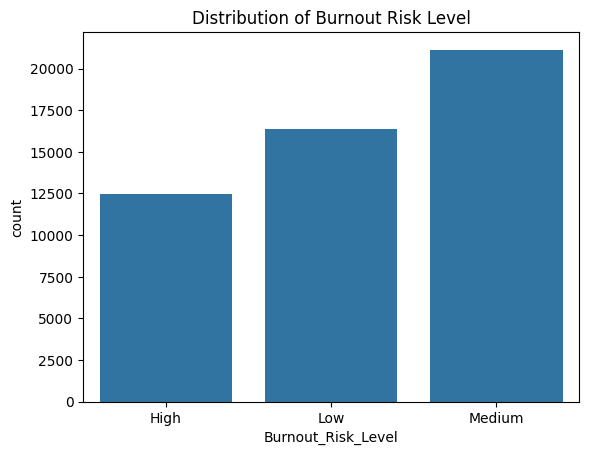

In [13]:
sns.countplot(x='Burnout_Risk_Level', data=df)
plt.title("Distribution of Burnout Risk Level")
plt.show()

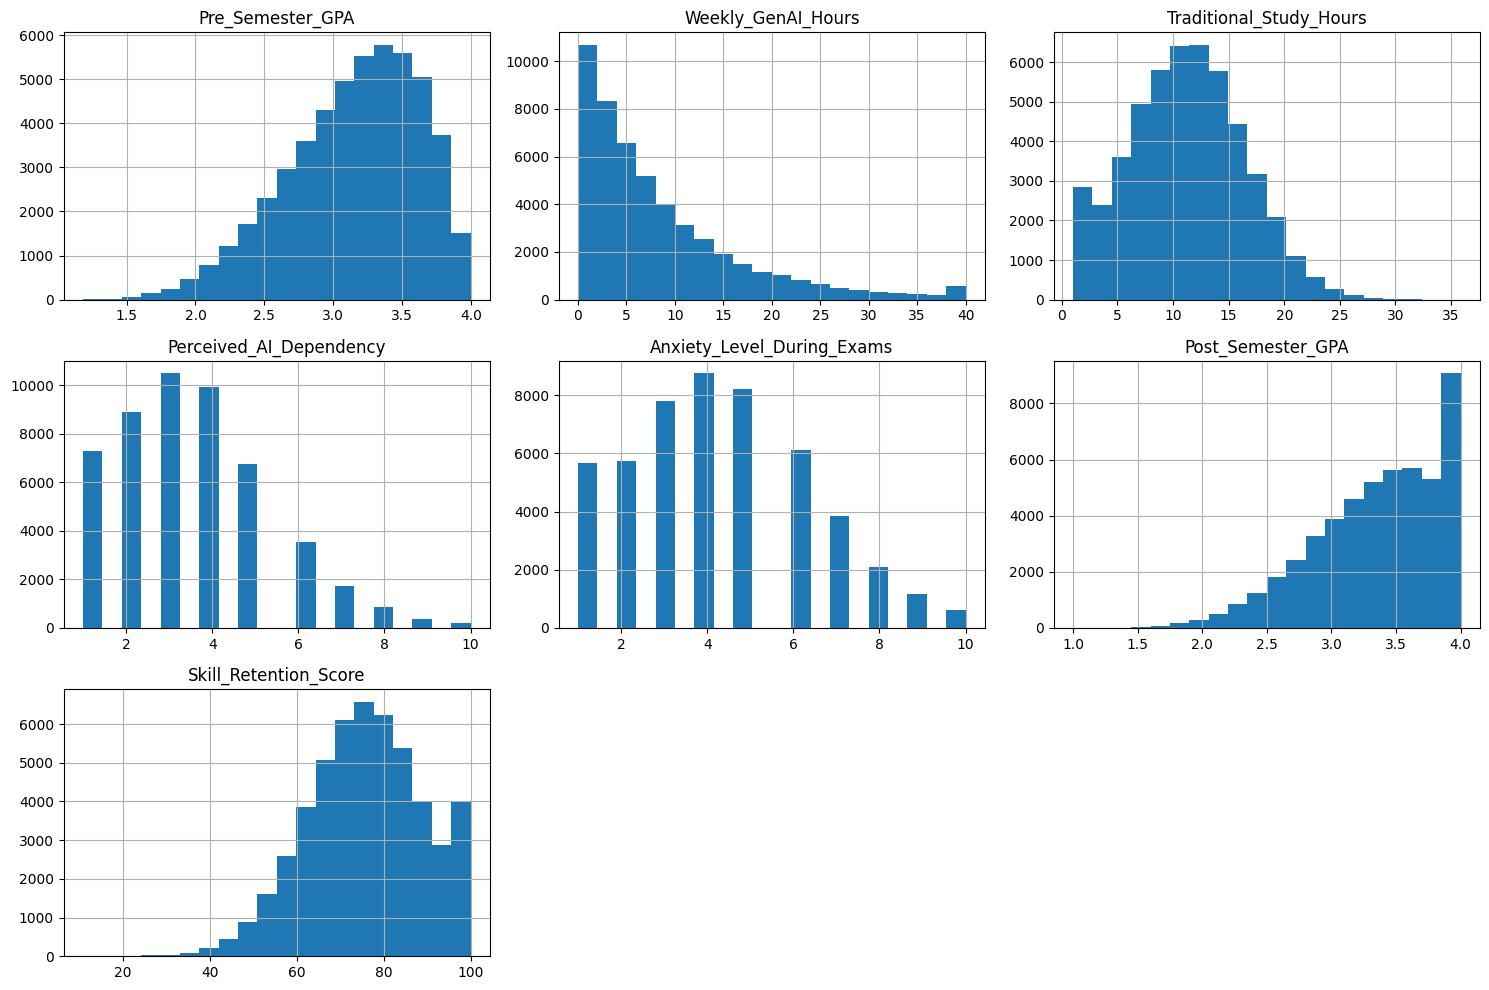

In [14]:
df.hist(figsize=(15,10), bins=20)
plt.tight_layout()
plt.show()

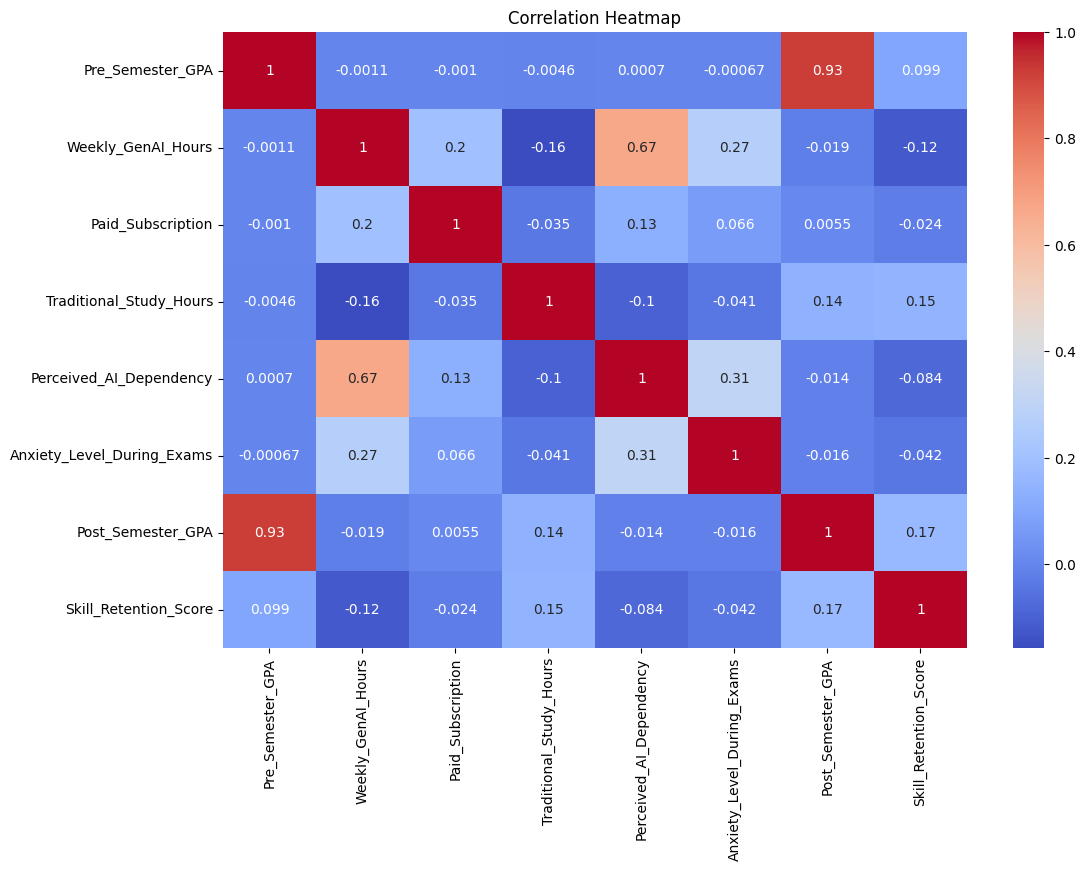

In [15]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

<Axes: xlabel='Burnout_Risk_Level', ylabel='Weekly_GenAI_Hours'>

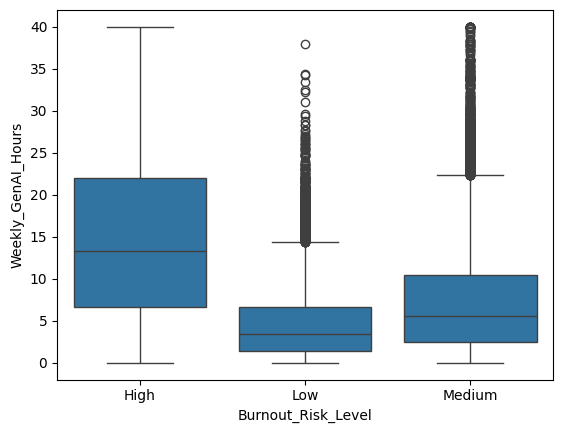

In [16]:
sns.boxplot(
    x='Burnout_Risk_Level',
    y='Weekly_GenAI_Hours',
    data=df
)

<Axes: xlabel='Burnout_Risk_Level', ylabel='Traditional_Study_Hours'>

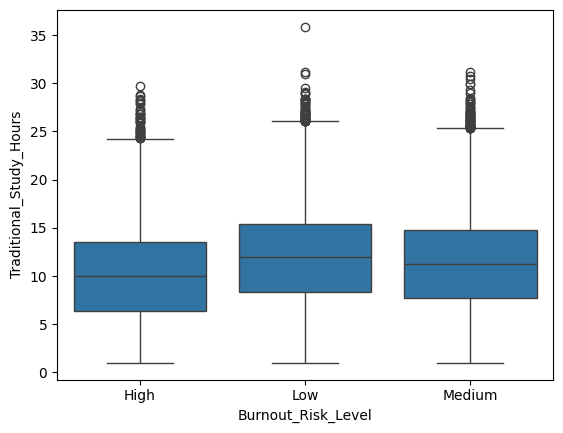

In [17]:
sns.boxplot(
    x='Burnout_Risk_Level',
    y='Traditional_Study_Hours',
    data=df
)

<Axes: xlabel='Anxiety_Level_During_Exams', ylabel='count'>

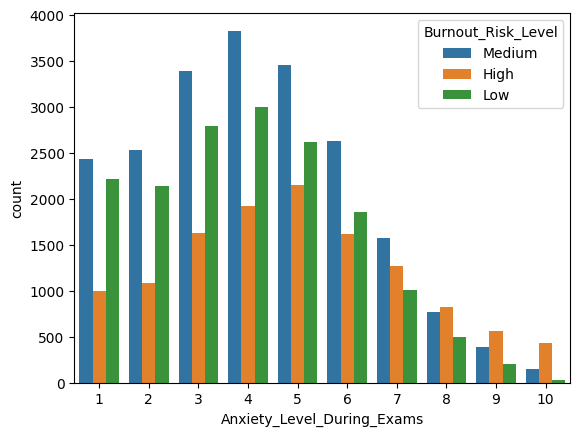

In [18]:
sns.countplot(
    x='Anxiety_Level_During_Exams',
    hue='Burnout_Risk_Level',
    data=df
)

<Axes: xlabel='Prompt_Engineering_Skill', ylabel='count'>

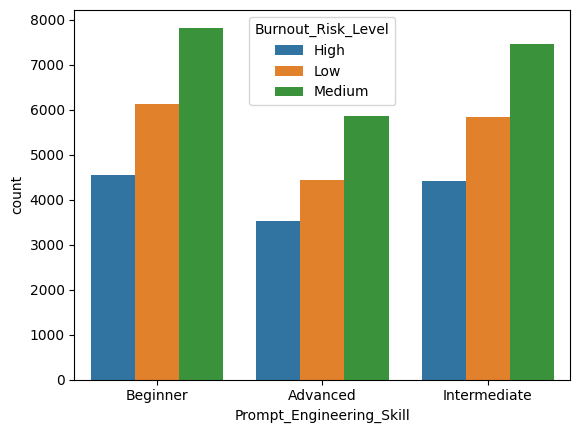

In [19]:
sns.countplot(
    x='Prompt_Engineering_Skill',
    hue='Burnout_Risk_Level',
    data=df
)

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Humanities'),
  Text(1, 0, 'Medical'),
  Text(2, 0, 'Business'),
  Text(3, 0, 'STEM'),
  Text(4, 0, 'Arts')])

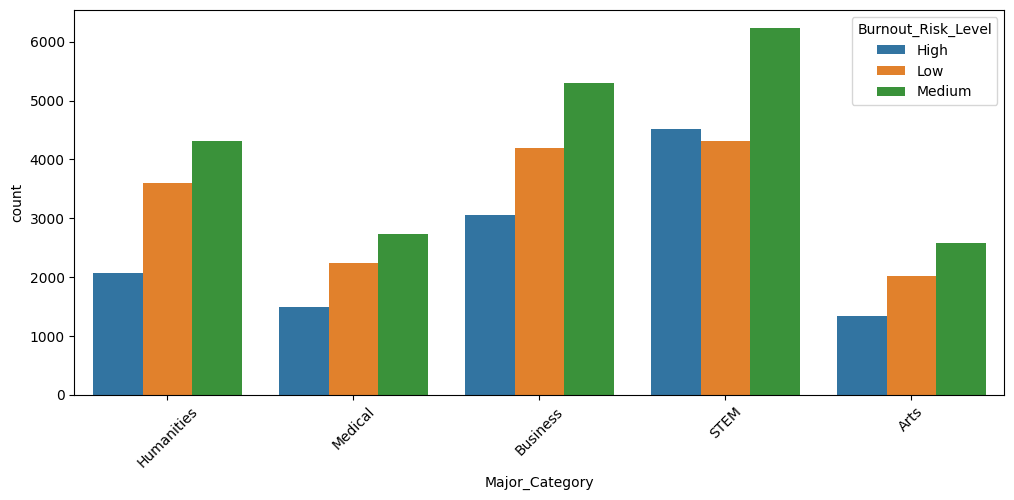

In [20]:
plt.figure(figsize=(12,5))
sns.countplot(
    x='Major_Category',
    hue='Burnout_Risk_Level',
    data=df
)
plt.xticks(rotation=45)

<Axes: xlabel='Year_of_Study', ylabel='count'>

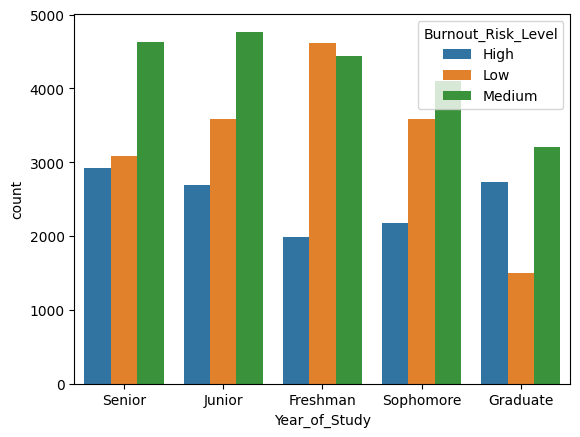

In [21]:
sns.countplot(
    x='Year_of_Study',
    hue='Burnout_Risk_Level',
    data=df
)

<Axes: xlabel='Year_of_Study', ylabel='count'>

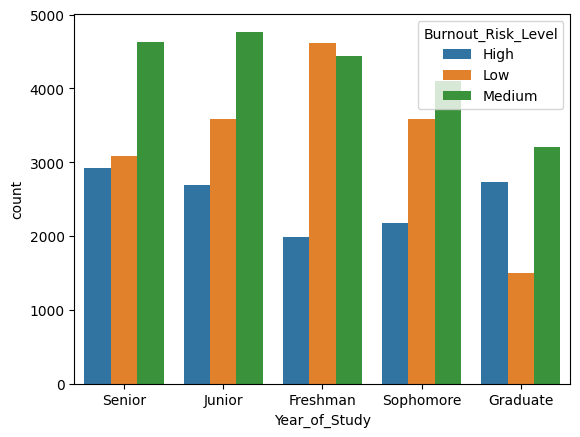

In [22]:
sns.countplot(
    x='Year_of_Study',
    hue='Burnout_Risk_Level',
    data=df
)

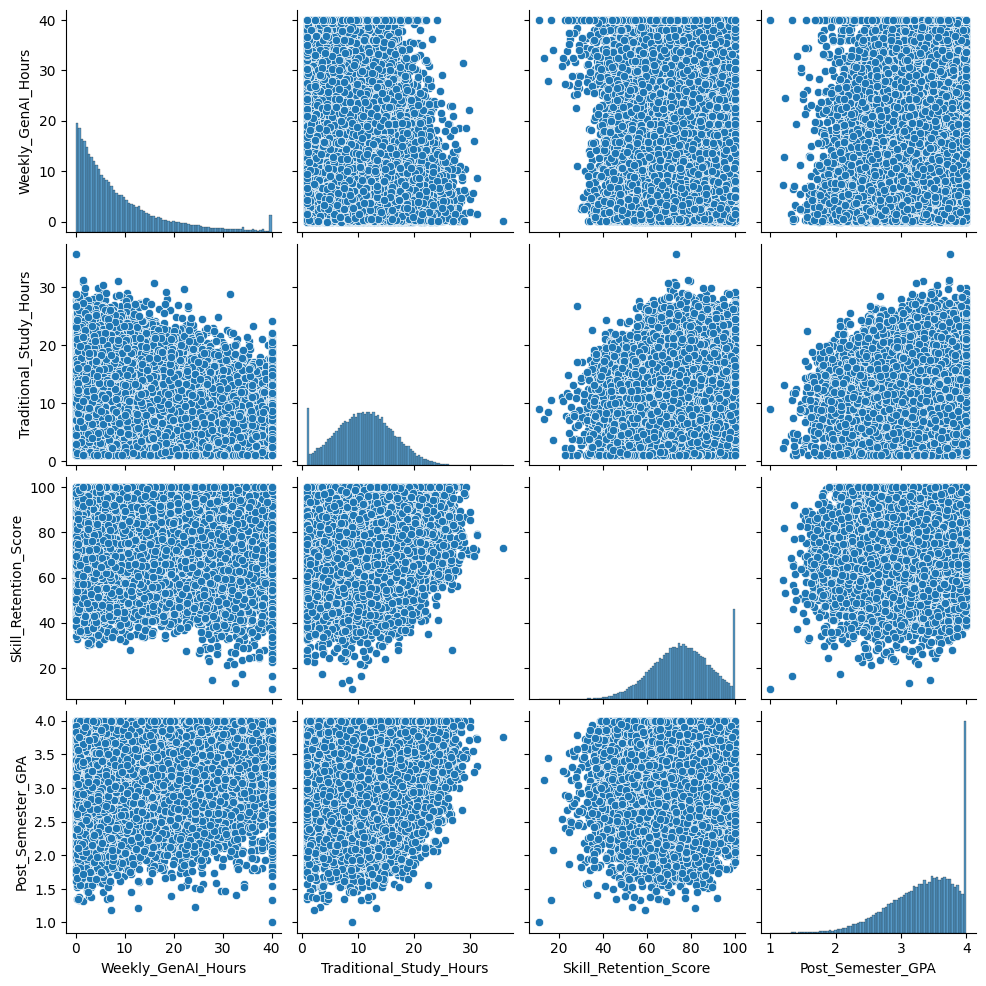

In [23]:
sns.pairplot(
    df[
        [
            'Weekly_GenAI_Hours',
            'Traditional_Study_Hours',
            'Skill_Retention_Score',
            'Post_Semester_GPA'
        ]
    ]
)

<Axes: xlabel='Burnout_Risk_Level', ylabel='Skill_Retention_Score'>

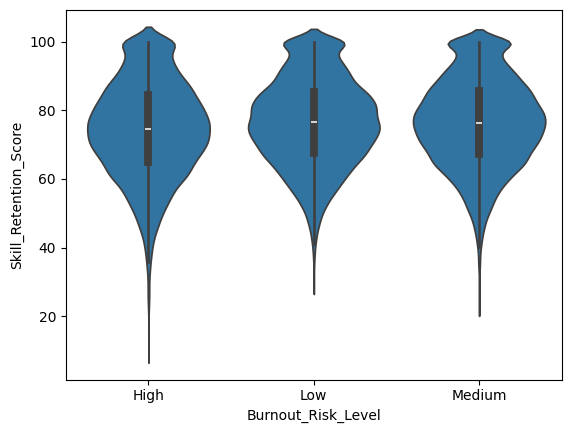

In [24]:
sns.violinplot(
    x='Burnout_Risk_Level',
    y='Skill_Retention_Score',
    data=df
)

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.metrics import accuracy_score,confusion_matrix

In [26]:
df.head()

,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,Medical,Junior,3.821,1.12,Ideation,Advanced,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


In [27]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Major_Category              50000 non-null  object 
 1   Year_of_Study               50000 non-null  object 
 2   Pre_Semester_GPA            50000 non-null  float64
 3   Weekly_GenAI_Hours          50000 non-null  float64
 4   Primary_Use_Case            50000 non-null  object 
 5   Prompt_Engineering_Skill    50000 non-null  object 
 6   Paid_Subscription           50000 non-null  bool   
 7   Traditional_Study_Hours     50000 non-null  float64
 8   Perceived_AI_Dependency     50000 non-null  int64  
 9   Institutional_Policy        50000 non-null  object 
 10  Anxiety_Level_During_Exams  50000 non-null  int64  
 11  Post_Semester_GPA           50000 non-null  float64
 12  Skill_Retention_Score       50000 non-null  float64
 13  Burnout_Risk_Level          500

In [35]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num',StandardScaler(),['Pre_Semester_GPA','Weekly_GenAI_Hours','Traditional_Study_Hours','Anxiety_Level_During_Exams','Post_Semester_GPA','Skill_Retention_Score']),
        ('cat',OneHotEncoder(),['Major_Category','Year_of_Study','Primary_Use_Case','Prompt_Engineering_Skill','Paid_Subscription','Institutional_Policy'])
    ]
)
model_pipeline = Pipeline(
    steps=[
        ('preprocessor',preprocessor),
        ('classifier',LogisticRegression())
    ]
)

In [36]:
X = df.drop(columns=['Burnout_Risk_Level'])
y = df['Burnout_Risk_Level']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [37]:
model_pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Pre_Semester_GPA',
                                                   'Weekly_GenAI_Hours',
                                                   'Traditional_Study_Hours',
                                                   'Anxiety_Level_During_Exams',
                                                   'Post_Semester_GPA',
                                                   'Skill_Retention_Score']),
                                                 ('cat', OneHotEncoder(),
                                                  ['Major_Category',
                                                   'Year_of_Study',
                                                   'Primary_Use_Case',
                                                   'Prompt_Engineering_Skill',
                                                   'Paid_Subscription',
                                                   'Institutional_Policy'])])),
                ('classifier', LogisticRegression())])

In [38]:
y_pred = model_pipeline.predict(X_test)

In [39]:
accuracy_score(y_test,y_pred)

0.537

<Axes: xlabel='Post_Semester_GPA', ylabel='Count'>

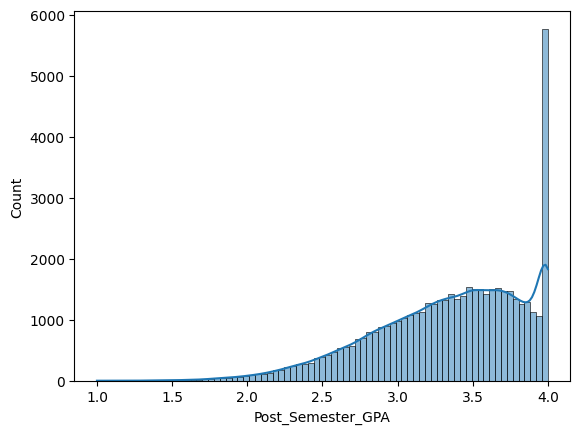

In [40]:
sns.histplot(df['Post_Semester_GPA'], kde=True)

<Axes: xlabel='Pre_Semester_GPA', ylabel='Post_Semester_GPA'>

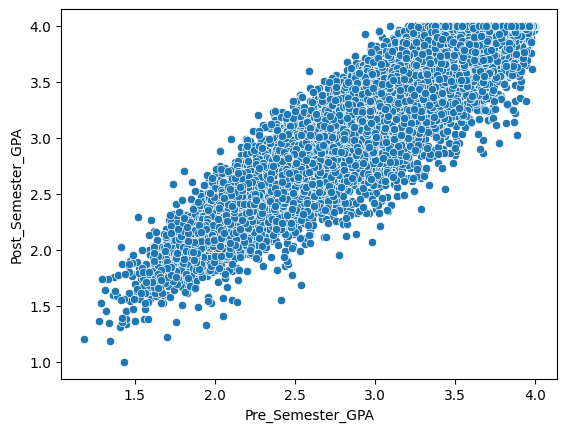

In [41]:
sns.scatterplot(
    x='Pre_Semester_GPA',
    y='Post_Semester_GPA',
    data=df
)

<Axes: xlabel='Weekly_GenAI_Hours', ylabel='Post_Semester_GPA'>

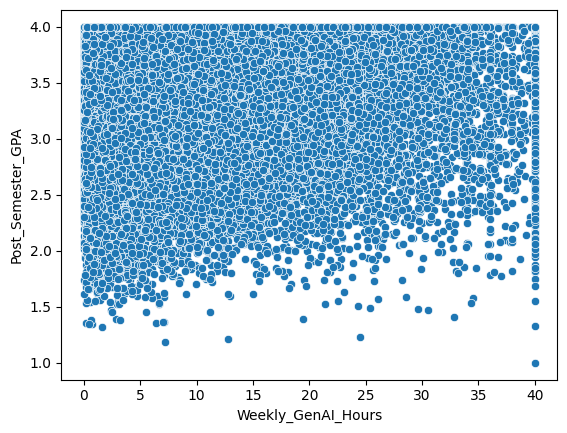

In [42]:
sns.scatterplot(
    x='Weekly_GenAI_Hours',
    y='Post_Semester_GPA',
    data=df
)

<Axes: xlabel='Traditional_Study_Hours', ylabel='Post_Semester_GPA'>

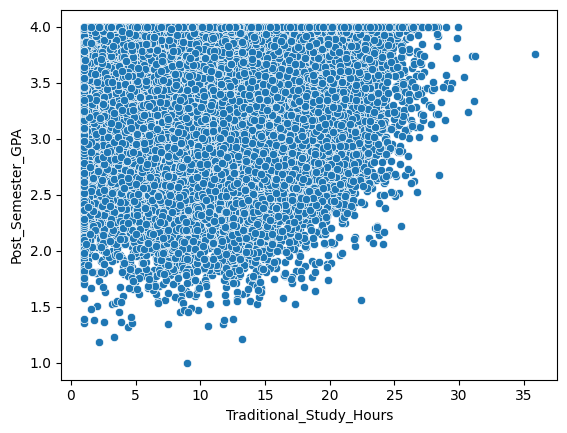

In [43]:
sns.scatterplot(
    x='Traditional_Study_Hours',
    y='Post_Semester_GPA',
    data=df
)

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Humanities'),
  Text(1, 0, 'Medical'),
  Text(2, 0, 'Business'),
  Text(3, 0, 'STEM'),
  Text(4, 0, 'Arts')])

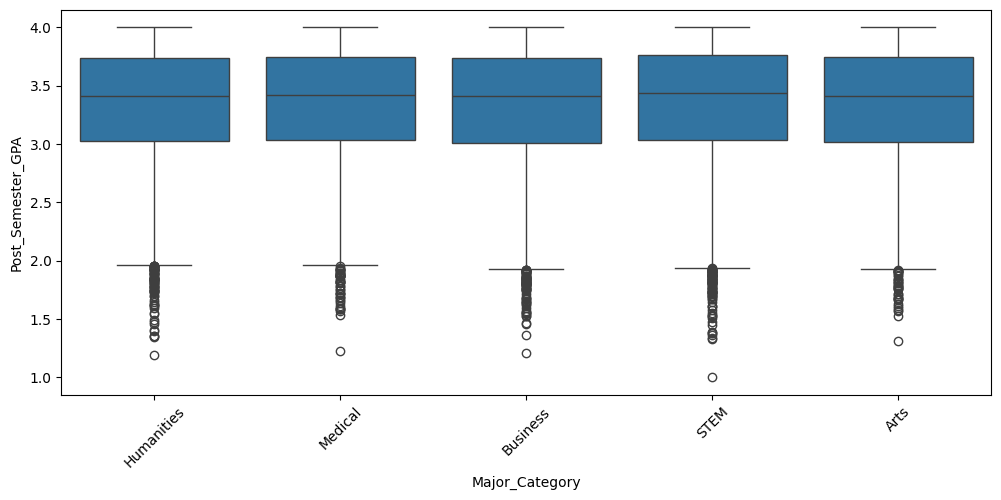

In [44]:
plt.figure(figsize=(12,5))
sns.boxplot(
    x='Major_Category',
    y='Post_Semester_GPA',
    data=df
)
plt.xticks(rotation=45)

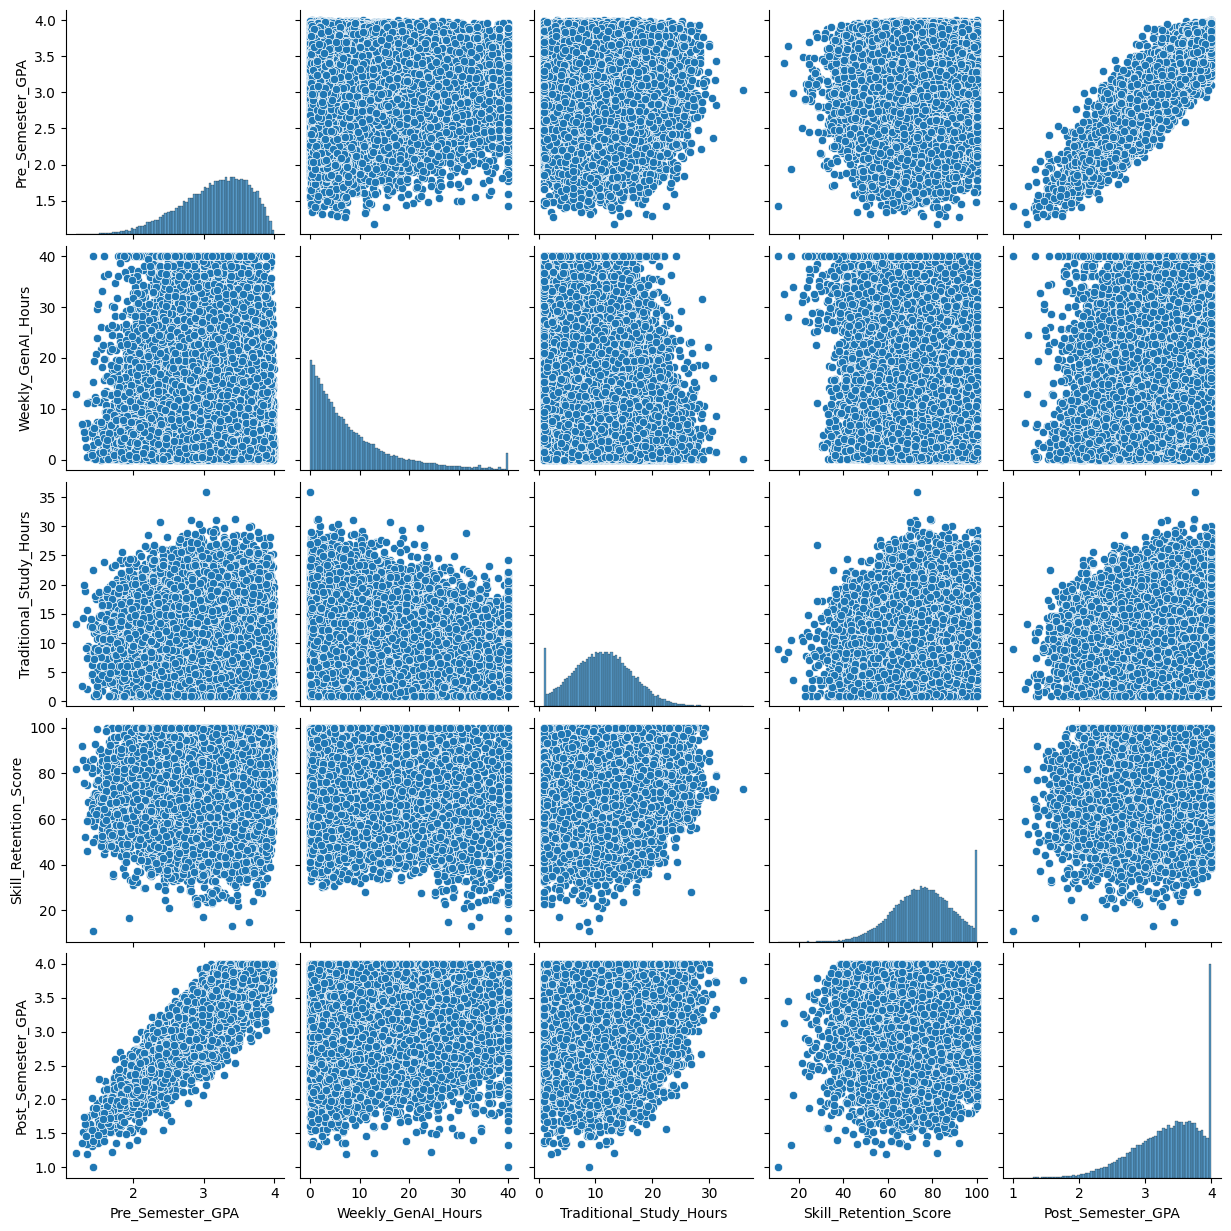

In [45]:
sns.pairplot(
    df[
        [
            'Pre_Semester_GPA',
            'Weekly_GenAI_Hours',
            'Traditional_Study_Hours',
            'Skill_Retention_Score',
            'Post_Semester_GPA'
        ]
    ]
)

<Axes: xlabel='Pre_Semester_GPA', ylabel='Post_Semester_GPA'>

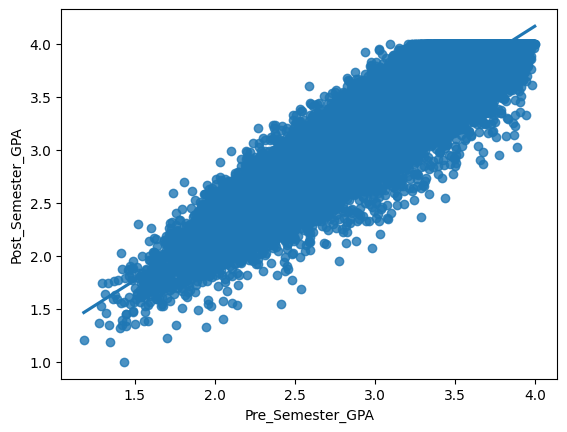

In [46]:
sns.regplot(
    x='Pre_Semester_GPA',
    y='Post_Semester_GPA',
    data=df
)